# [BDA_FINDA1기] OTT 카드가입예측 프로젝트 코드

제출자: 이호준_4083

## <문제정의> : "OTT 제휴카드 가입 고객 예측을 위한 고객 단위 소비 패턴 분석”

### 세부 목표
- 기존 가입된 고객 별 특성을 파악하여 가입하지 않은 고객의 잠재적 특성을 이해한다.

- 고객들의 특성간의 상관관계를 파악함으로써 어떠한 요소가 가입의 직접적인 영향을 미칠 수 있는지 파악한다.

- 로지스틱 회귀 모델을 활용하여 고객별 제휴카드 가입 확률을 예측하고,
마케팅 타겟팅에 활용 가능한 고가입 가능 고객군을 정의한다.

### 카드사 입장
- 제휴카드를 통한 서비스를 통해 신규 유저의 가입을 촉구한다.

## **1. 데이터 파악**

In [1]:
# 한글 폰트 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

In [167]:
# 기본 라이브러리 가져오기
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as spst
import matplotlib.font_manager as fm

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

# 한글 폰트 설정

# 폰트가 제대로 설정되었는지 확인
try:
    plt.rc('font', family='NanumBarunGothic')
    plt.rcParams['axes.unicode_minus'] = False
    print("NanumBarunGothic 폰트가 성공적으로 설정되었습니다.")
except ValueError:
    print("WARNING: NanumBarunGothic 폰트를 찾을 수 없습니다. 폰트 설치 셀 실행 후, Colab 런타임을 재시작(런타임 -> 런타임 다시 시작)하고 모든 셀을 다시 실행해 주세요.")

# 현재 폰트 확인 (디버깅용)
print(f"Current matplotlib font family setting: {plt.rcParams['font.family']}")
print(f"Minus sign unicode setting: {plt.rcParams['axes.unicode_minus']}")

NanumBarunGothic 폰트가 성공적으로 설정되었습니다.
Current matplotlib font family setting: ['NanumBarunGothic']
Minus sign unicode setting: False


In [3]:
# 기본 자료 가져오기
path_member = '/content/TB_MEMBER.csv'
path_sales = '/content/TB_SALES.csv'

In [4]:
# TB_MEMBER 읽어오기
tb_member = pd.read_csv(path_member)
tb_member.head()

,CustID,Age,Gender,Region,CardHolder,NumCards,CreditScore,SignUp
0,1,56,F,Daejeon,Y,1,653.542443,1
1,2,69,F,Busan,Y,4,687.782277,0
2,3,46,M,Seoul,N,0,512.120492,0
3,4,32,M,Other,N,0,563.897020,0
4,5,60,M,Busan,Y,3,591.352955,1


In [5]:
# TB_SALES 읽어오기
tb_sales = pd.read_csv(path_sales, encoding='cp949')
tb_sales.head()

,CustID,Date,Category,Amount
0,1,2024-08-15,마트,229.18
1,1,2024-01-22,마트,260.44
2,1,2024-06-27,식당,60.57
3,1,2024-01-28,식당,186.85
4,1,2024-11-13,OTT,11.95


In [6]:
# TB_MEMBERS과 TB_SALES의 기초 통계량(숫자형)
print(tb_member[['Age', 'NumCards', 'CreditScore', 'SignUp']].describe())
print('------------------------------------------------------------')
print(tb_sales[['Amount']].describe())

               Age     NumCards  CreditScore       SignUp
count  1000.000000  1000.000000   980.000000  1000.000000
mean     50.380000     2.388000   617.246090     0.351000
std      18.378666     1.747143   136.293100     0.477522
min      18.000000     0.000000   300.000000     0.000000
25%      35.000000     1.000000   518.634928     0.000000
50%      50.000000     2.000000   615.163374     0.000000
75%      66.000000     4.000000   717.580764     1.000000
max      80.000000     5.000000   900.000000     1.000000
------------------------------------------------------------
             Amount
count  98889.000000
mean     150.696551
std      203.834515
min        1.000000
25%       25.330000
50%       72.930000
75%      182.570000
max      999.880000


In [7]:
# 기타 범주형 데이터 통계량
# 성별의 총합수
Gender_COUNT = tb_member['Gender'].value_counts()
print(Gender_COUNT)
# 성별의 비율
Gender_RATIO = tb_member['Gender'].value_counts(normalize=True)
print(Gender_RATIO)
print('----------------------------------')
# 지역의 총합수
Region_COUNT = tb_member['Region'].value_counts()
print(Region_COUNT)
# 지역의 비율
Region_RATIO = tb_member['Region'].value_counts(normalize=True)
print(Region_RATIO)
print('----------------------------------')
# 카드의 총합수
Card_COUNT = tb_member['CardHolder'].value_counts()
print(Card_COUNT)
# 카드의 비율
Card_RATIO = tb_member['CardHolder'].value_counts(normalize=True)
print(Card_RATIO)


Gender
F    523
M    477
Name: count, dtype: int64
Gender
F    0.523
M    0.477
Name: proportion, dtype: float64
----------------------------------
Region
Other      214
Busan      212
Gwangju    208
Seoul      192
Daejeon    174
Name: count, dtype: int64
Region
Other      0.214
Busan      0.212
Gwangju    0.208
Seoul      0.192
Daejeon    0.174
Name: proportion, dtype: float64
----------------------------------
CardHolder
Y    800
N    200
Name: count, dtype: int64
CardHolder
Y    0.8
N    0.2
Name: proportion, dtype: float64


### **[TB_MEMBERS을 통한 그래프 분석]**

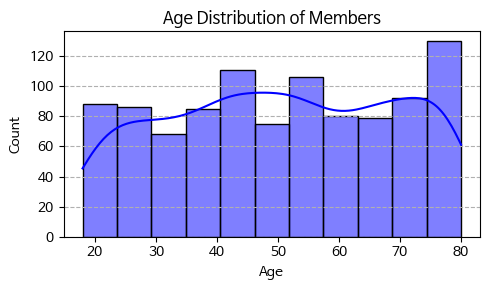

In [8]:
# TB_MEMBERS의 각각 분석표
# 성별에 의한 분포
plt.figure(figsize=(5, 3))
sns.histplot(tb_member['Age'], kde=True, color='blue')
plt.title('Age Distribution of Members')
plt.xlabel('Age')
plt.grid(axis='y', linestyle='--', )
plt.tight_layout()
plt.show()

/tmp/ipython-input-584132003.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=tb_member['Region'], order=tb_member['Region'].value_counts().index, palette='viridis')


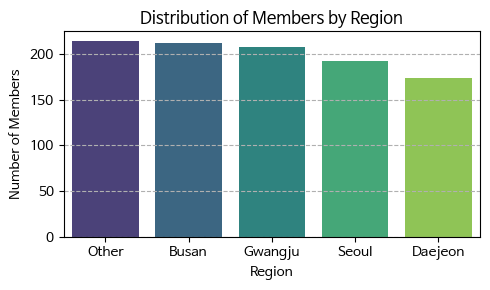

In [9]:
# 지역에 의한 분포

plt.figure(figsize=(5, 3))
sns.countplot(x=tb_member['Region'], order=tb_member['Region'].value_counts().index, palette='viridis')
plt.title('Distribution of Members by Region')
plt.xlabel('Region')
plt.ylabel('Number of Members')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

/tmp/ipython-input-1371925969.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='CardHolder', data=tb_member, palette='pastel')


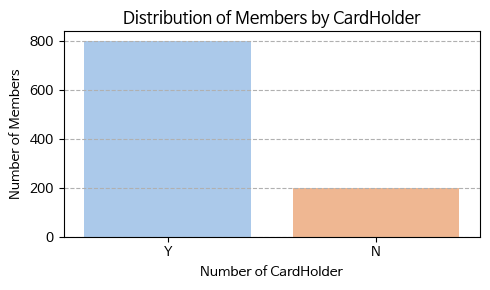

In [10]:
#카드 유무에 의한 분포
plt.figure(figsize=(5, 3))
sns.countplot(x='CardHolder', data=tb_member, palette='pastel')
plt.title('Distribution of Members by CardHolder')
plt.xlabel('Number of CardHolder')
plt.ylabel('Number of Members')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

/tmp/ipython-input-52286728.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='SignUp', data=tb_member, palette='pastel')


Text(0, 0.5, 'Number of Members')

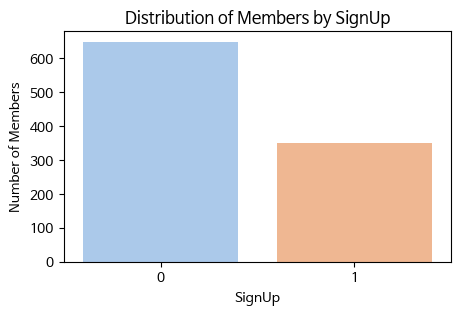

In [116]:
# 가입자별 분포
plt.figure(figsize=(5, 3))
sns.countplot(x='SignUp', data=tb_member, palette='pastel')
plt.title('Distribution of Members by SignUp')
plt.xlabel('SignUp')
plt.ylabel('Number of Members')

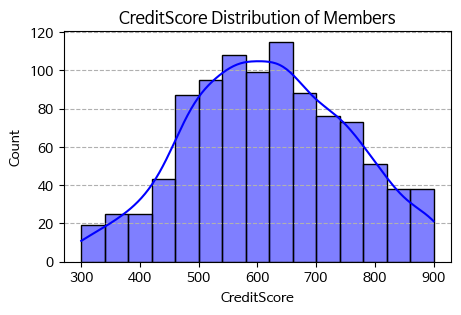

In [11]:
# 신용점수에의한 분포
plt.figure(figsize=(5, 3))
sns.histplot(tb_member['CreditScore'], kde=True, color='blue')
plt.title('CreditScore Distribution of Members')
plt.grid(axis='y', linestyle='--' )
plt.show()

### **[TB_MEMBERS을 통한 그래프 분석 설명]**


1.   현재 멤버들의 나이는 50대 즉, 중장년 층이 주를 이루고 있다.
2.   카드를 보유한자가 80%이며, 2개를 소유한 분들이 가장 많았다.



### **[TB_SALES을 통한 그래프 분석]**

In [12]:
# 기타 범주형 데이터 통계량
# Category의 총합수
Category_COUNT = tb_sales['Category'].value_counts()
print(Category_COUNT)
# Category의 비율
Category_RATIO = tb_sales['Category'].value_counts(normalize=True)
print(Category_RATIO)
print('----------------------------------')


Category
편의점    24220
마트     24182
식당     23920
여행     14797
OTT    11770
Name: count, dtype: int64
Category
편의점    0.244921
마트     0.244537
식당     0.241887
여행     0.149632
OTT    0.119022
Name: proportion, dtype: float64
----------------------------------


/tmp/ipython-input-2774189501.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Category', data=tb_sales, order=tb_sales['Category'].value_counts().index, palette='viridis')


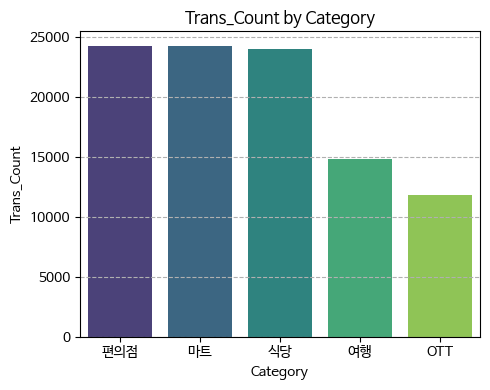

In [29]:
# Category별 거래 건수 분석
plt.figure(figsize=(5, 4))
sns.countplot(x='Category', data=tb_sales, order=tb_sales['Category'].value_counts().index, palette='viridis')
plt.title('Trans_Count by Category')
plt.xlabel('Category')
plt.ylabel('Trans_Count')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

/tmp/ipython-input-398195575.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_amount.index, y=np.log1p(category_amount.values), palette='viridis') # 로그 변환 적용


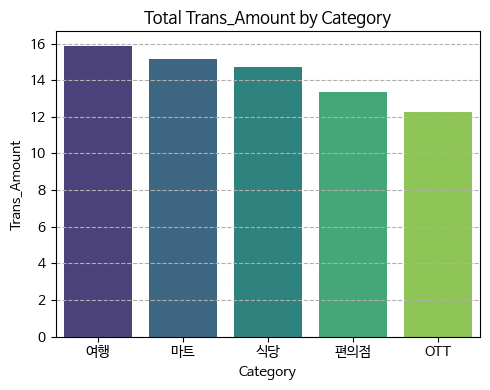

In [28]:
# Category별 Amount 분석

# 카테고리별 금액 합계 계산
category_amount = tb_sales.groupby('Category')['Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(5, 4))
sns.barplot(x=category_amount.index, y=np.log1p(category_amount.values), palette='viridis') # 로그 변환 적용
plt.title('Total Trans_Amount by Category')
plt.xlabel('Category')
plt.ylabel('Trans_Amount')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

### **[TB_SALES을 통한 그래프 분석 설명]**


1.   거래의 카테고리는 주로 편의점, 마트, 식당으로 이루어졌다.
2.   거래의 총량은 여행이 가장 많았고, 마트, 식당 순으로 이루어졌다.


## **2. 데이터 집계**

### **TB_CUST_AGG(고객집계테이블)**
- 각각의 테이블인 TB_MEMBER와 TB_SALES를 고객단위로 병합 및 집계한다.
- TB_CUST_AGG의 주요단위는 다음과 같다.
    - **'TOTAL_AMOUNT'** : 총 거래 금액
    - **'TOTAL_TRANS'** : 총 거래 수
    - **'OTT_AMOUNT'** : OTT 지출액
    - **'기타 카테고리별 AMOUT'**


In [91]:
# Cust_ID를 통해 데이터 통합 : TB_CUST_AGG

tb_cust_agg = tb_sales.groupby('CustID').agg(
    TotalTrans=('Amount', 'count'),
    TotalAmount=('Amount', 'sum'),
)

print(tb_cust_agg)

        TotalTrans  TotalAmount
CustID                         
1              123     15013.43
2               34      5084.65
3              123     12221.57
4              161     27546.52
5              179     29830.84
...            ...          ...
996            113     14218.73
997            162     25781.03
998            167     24775.16
999             97     11368.80
1000            83     13132.95

[1000 rows x 2 columns]


In [92]:
# Cust_ID별로 카테고리 종류에 따른 거래 횟수와 양
cust_category_pivot = cust_category_agg.pivot_table(index='CustID', columns='Category', values='Amount_Category', fill_value=0)
print(cust_category_pivot)


Category     OTT       마트       식당        여행      편의점
CustID                                               
1         778.08  3742.81  3164.61   6985.84   342.09
2           7.50  1452.24  1426.01   1967.71   231.19
3         604.40  3840.48  2453.83   4789.23   533.63
4         207.61  7574.41  3516.92  15168.33  1079.25
5         349.63  6633.27  4438.84  17228.24  1180.86
...          ...      ...      ...       ...      ...
996       283.87  3785.65  2972.27   6546.31   630.63
997        23.85  5646.32  5341.20  13404.96  1364.70
998       679.47  5184.17  4257.73  13817.32   836.47
999       365.90  2857.48  1612.83   5891.44   641.15
1000        0.00  3145.13  2456.83   7007.39   523.60

[1000 rows x 5 columns]


In [93]:
# OTT를 OTT_AMOUNT로 변경 후 TB_CUST_AGG와 합치기
tb_cust_agg = pd.merge(tb_cust_agg, cust_category_pivot, on='CustID', how='left')
tb_cust_agg.head()


,TotalTrans,TotalAmount,OTT,마트,식당,여행,편의점
CustID,,,,,,,
1,123,15013.43,778.08,3742.81,3164.61,6985.84,342.09
2,34,5084.65,7.50,1452.24,1426.01,1967.71,231.19
3,123,12221.57,604.40,3840.48,2453.83,4789.23,533.63
4,161,27546.52,207.61,7574.41,3516.92,15168.33,1079.25
5,179,29830.84,349.63,6633.27,4438.84,17228.24,1180.86


In [97]:
# 각각의 카테고리별 이름을 변경
tb_cust_agg.rename(columns={'OTT': 'OTT_AMOUNT'}, inplace=True)
tb_cust_agg.rename(columns={'마트': 'Mart_AMOUNT'}, inplace=True)
tb_cust_agg.rename(columns={'식당': 'Restaurant_AMOUNT'}, inplace=True)
tb_cust_agg.rename(columns={'여행': 'Travel_AMOUNT'}, inplace=True)
tb_cust_agg.rename(columns={'편의점': 'Convenience_AMOUNT'}, inplace=True)
tb_cust_agg

,TotalTrans,TotalAmount,OTT_AMOUNT,Mart_AMOUNT,Restaurant_AMOUNT,Travel_AMOUNT,Convenience_AMOUNT
CustID,,,,,,,
1,123,15013.43,778.08,3742.81,3164.61,6985.84,342.09
2,34,5084.65,7.50,1452.24,1426.01,1967.71,231.19
3,123,12221.57,604.40,3840.48,2453.83,4789.23,533.63
4,161,27546.52,207.61,7574.41,3516.92,15168.33,1079.25
5,179,29830.84,349.63,6633.27,4438.84,17228.24,1180.86
...,...,...,...,...,...,...,...
996,113,14218.73,283.87,3785.65,2972.27,6546.31,630.63
997,162,25781.03,23.85,5646.32,5341.20,13404.96,1364.70
998,167,24775.16,679.47,5184.17,4257.73,13817.32,836.47


## **3. 로지스틱 회귀**

### **어떤 변수에 변화를 주어야 할까?(가설)**
- **가설의 종류**
    - **'AGE'** : 중장년층들을 위한 혜택을 추가하면 가입이 증가할 것이다.
    - **'NumCards'** : 카드 수가 많을 수록 신규 카드 가입이 저하될 것이다.
    - **'TotalTrans'** : 거래횟수가 많을 수록 카드 혜택에 대한 활용도가 높아 가입할 가능성이 높을 것이다.
    - **'OTT_AMOUNT'** : OTT의 지출이 높은 고객일 수록, OTT제휴카드에 대한 관심도와 신규가입이 많을 것이다.
    - **'CreditScore'** : 신용등급이 높을 수록 받는 혜택이 많아지고 그로 인해 가입할 가능성이 높다.

In [103]:
# TB_MEMBER와 TB_CUST_AGG를 합친 테이블 생성
total_data = pd.merge(tb_member, tb_cust_agg, on='CustID', how='inner')
total_data

,CustID,Age,Gender,Region,CardHolder,NumCards,CreditScore,SignUp,TotalTrans,TotalAmount,OTT_AMOUNT,Mart_AMOUNT,Restaurant_AMOUNT,Travel_AMOUNT,Convenience_AMOUNT
0,1,56,F,Daejeon,Y,1,653.542443,1,123,15013.43,778.08,3742.81,3164.61,6985.84,342.09
1,2,69,F,Busan,Y,4,687.782277,0,34,5084.65,7.50,1452.24,1426.01,1967.71,231.19
2,3,46,M,Seoul,N,0,512.120492,0,123,12221.57,604.40,3840.48,2453.83,4789.23,533.63
3,4,32,M,Other,N,0,563.897020,0,161,27546.52,207.61,7574.41,3516.92,15168.33,1079.25
4,5,60,M,Busan,Y,3,591.352955,1,179,29830.84,349.63,6633.27,4438.84,17228.24,1180.86
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,78,M,Gwangju,N,0,524.410470,0,113,14218.73,283.87,3785.65,2972.27,6546.31,630.63
996,997,23,F,Other,Y,3,790.759505,0,162,25781.03,23.85,5646.32,5341.20,13404.96,1364.70
997,998,35,M,Daejeon,Y,4,731.452979,1,167,24775.16,679.47,5184.17,4257.73,13817.32,836.47
998,999,68,F,Other,Y,5,NaN,1,97,11368.80,365.90,2857.48,1612.83,5891.44,641.15


### **<상관계수의 절대값이 1에 가까울 수록 강한 상관관계, 0에 가까울 수록 약한 상관관계>**

#### **중요한것은** 'OTT_AMOUT'와 다른 항목들간의 상관관계
  - 이유 : OTT_AMOUNT와 다른 항목들의 관계에 따라서 어떤 것이 영향력이 크게 발휘하는지 알아볼 수 있다.

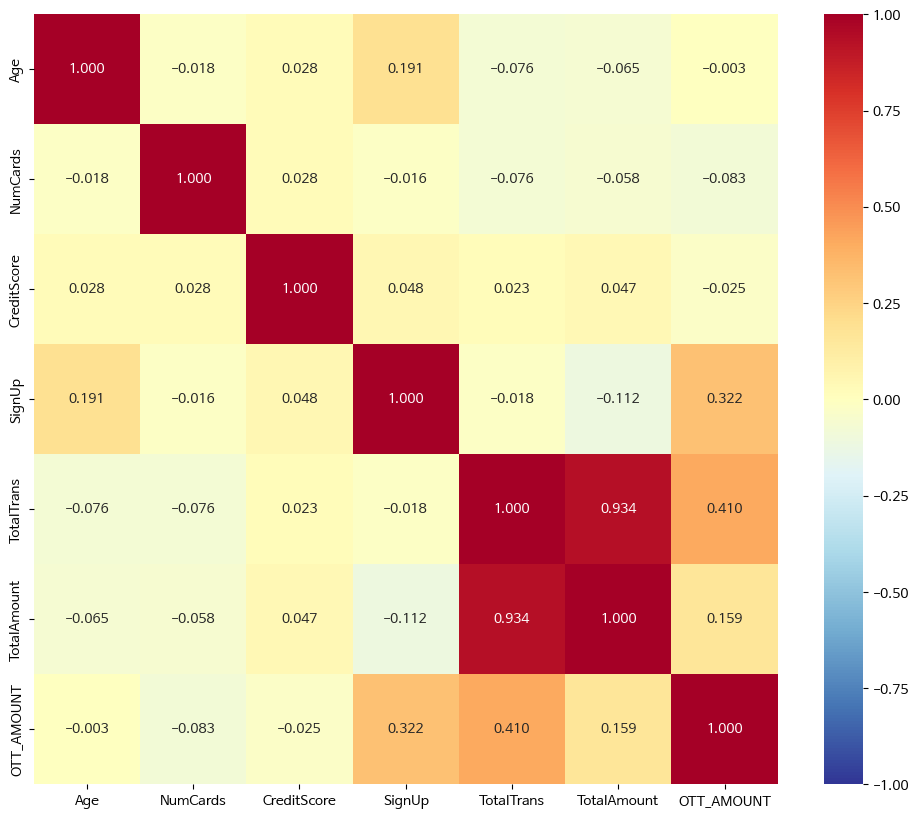

In [115]:
# 숫자형 컬럼만 선택하여 상관관계 계산
numeric_cols = total_data.select_dtypes(include=np.number).columns.drop(['CustID', 'Mart_AMOUNT', 'Restaurant_AMOUNT', 'Travel_AMOUNT', 'Convenience_AMOUNT'], errors='ignore')

plt.figure(figsize=(12, 10))
sns.heatmap(total_data[numeric_cols].corr(),
            annot = True,
            fmt = '.3f',
            cmap = 'RdYlBu_r',
            vmin = -1, vmax = 1)
plt.show()

### <강한 상관계수를 갖는 관계들>


1.   OTT_AMT - Total_Trans
2.   SignUp - OTT_Amt



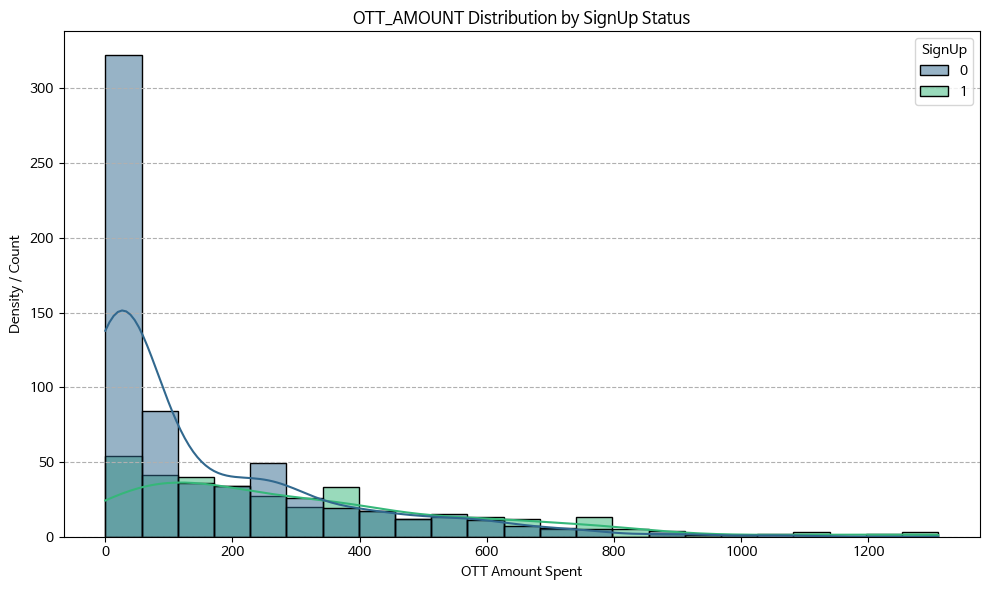

In [136]:
# 가입여부별 OTT_AMOUNT 분포
plt.figure(figsize=(10, 6))
sns.histplot(data=total_data, x='OTT_AMOUNT', hue='SignUp', kde=True, palette='viridis')
plt.title('OTT_AMOUNT Distribution by SignUp Status')
plt.xlabel('OTT Amount Spent')
plt.ylabel('Density / Count')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

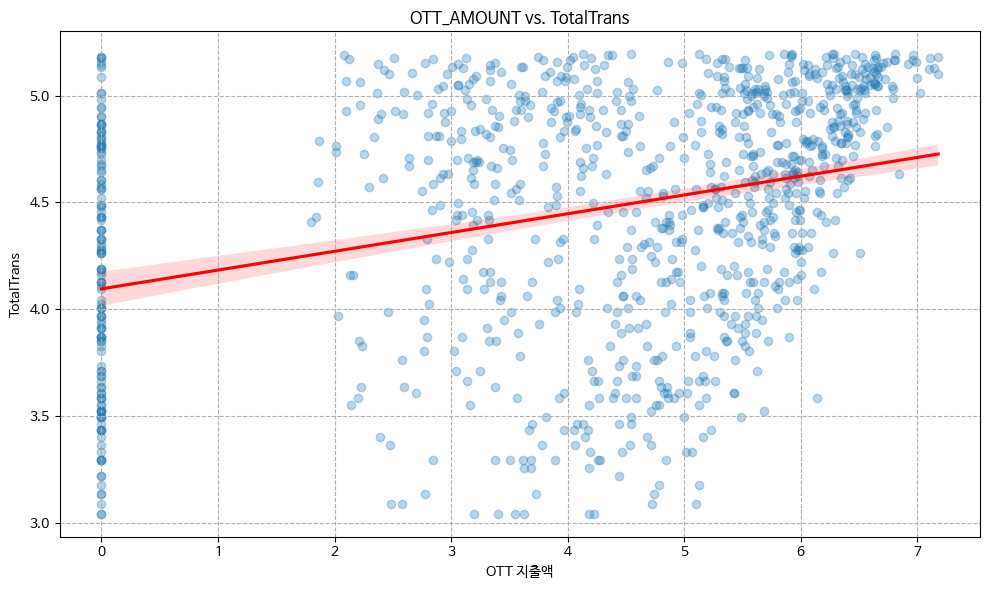

In [143]:
# OTT_AMOUNT와 TotalTrans 분포 (로그 변환 적용)
plt.figure(figsize=(10, 6))
sns.regplot(x=np.log1p(total_data['OTT_AMOUNT']), y=np.log1p(total_data['TotalTrans']), data=total_data, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('OTT_AMOUNT vs. TotalTrans')
plt.xlabel('OTT 지출액')
plt.ylabel('TotalTrans')
plt.grid(axis='both', linestyle='--')
plt.tight_layout()
plt.show()

### **<결과 해석>**
1. **가입자유무에 따른 OTT_AMT** : 두 그룹 모두 왼쪽(0근처)에 데이터가 몰려 있고 오른쪽으로 길게 늘어진 '우측 편향(Right-skewed)' 분포를 보인다. 즉, 대부분의 이용자는 적은 금액을 지출하며, 고액을 지출하는 이용자는 소수라는 뜻입니다.
2. **전체 거래에 따른 OTT_AMT** : 붉은색 실선(회귀선)이 오른쪽 위를 향하고 있다. 이는 OTT 지출액이 높을수록 전체 거래 횟수도 많은 경향이 있다는 것을 의미한다

In [159]:
# logistics를 위한 모델 데이터 프레임 형성

model_df = total_data[[
    "Age",
    "CreditScore",
    "TotalTrans",
    "NumCards",
    "TotalAmount"
]]

model_df

,Age,CreditScore,TotalTrans,NumCards,TotalAmount
0,56,653.542443,123,1,15013.43
1,69,687.782277,34,4,5084.65
2,46,512.120492,123,0,12221.57
3,32,563.897020,161,0,27546.52
4,60,591.352955,179,3,29830.84
...,...,...,...,...,...
995,78,524.410470,113,0,14218.73
996,23,790.759505,162,3,25781.03
997,35,731.452979,167,4,24775.16
998,68,NaN,97,5,11368.80


In [160]:
# 데이터 스케일링 및 훈련용과 검증용으로 데이터 분리
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

## **4. 로지스틱 회귀 모델 평가**

In [166]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print("f1-score", f1_score(y_test, y_pred))

Accuracy: 0.64
ROC AUC: 0.714090354090354
f1-score 0.5573770491803278


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
